---
title: "Assignment 2"
author: "Agustina Albez, Bora Abdik, Liam Hoogstad, Nour El Arrasse and Nurul Putri"
date: "2025-10-27"
format: 
  pdf:
    toc: true
    number-sections: true
    colorlinks: true
    include-in-header: 
      text: |
        \usepackage{fvextra}
        \DefineVerbatimEnvironment{Highlighting}{Verbatim}{breaklines,commandchars=\\\{\}}
        \DefineVerbatimEnvironment{OutputCode}{Verbatim}{breaklines,commandchars=\\\{\}}
highlight-style: zenburn
execute:
  echo: true
code-overflow: wrap
---
\newpage
\tableofcontents
\listoffigures
\listoftables
\newpage

# Import libraries

In [ ]:
library(dplyr)
library(ggplot2)
library(lubridate)

# Analysis

In [ ]:
# Downloading the data.
data = read.csv('sp500_2023_2024.csv') 

# change the type of datadate
data$datadate = as.Date(data$datadate, format = '%d/%m/%Y') 
head(select(data, tic, datadate, exchg, sic, cshtrd, prccd, prchd, prcld, prcod, gvkey))

# create a column to group the 7 day period under a week 
data$week = floor_date(data$datadate, "week", week_start = 1) 

# create a weekly data which is grouped by the weeks and tickers
weekly_data = data %>%
  group_by(conm, tic, week) %>%
  summarise(week_close = last(prccd), .groups = "drop") 
 # add the closing price in that week 

# Calculate the Simple weekly return for each week and ticker 
weekly_data = weekly_data %>% 
  group_by(tic) %>%
  mutate(week_ret_prc = 
    ((week_close - lag(week_close)) / lag(week_close))* 100) %>%
  ungroup()

weekly_data <- weekly_data %>%
  mutate(week_ret_prc = round(week_ret_prc, 3))

head(weekly_data, 5) 


,tic,datadate,exchg,sic,cshtrd,prccd,prchd,prcld,prcod,gvkey
,<chr>,<date>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,PNW,2023-01-03,11,4911,1442534,74.63,76.4125,73.380,76.25,1075
2,PNW,2023-01-04,11,4911,954218,75.39,76.0950,74.630,75.10,1075
3,PNW,2023-01-05,11,4911,994775,73.65,75.0950,73.305,74.88,1075
4,PNW,2023-01-06,11,4911,729808,75.46,76.0200,74.480,74.49,1075
5,PNW,2023-01-09,11,4911,656127,75.55,76.4800,75.240,75.24,1075
6,PNW,2023-01-10,11,4911,763254,75.65,75.6950,74.880,75.31,1075


conm,tic,week,week_close,week_ret_prc
<chr>,<chr>,<date>,<dbl>,<dbl>
3M CO,MMM,2023-01-02,126.72,NA
3M CO,MMM,2023-01-09,129.51,2.202
3M CO,MMM,2023-01-16,120.65,-6.841
3M CO,MMM,2023-01-23,115.25,-4.476
3M CO,MMM,2023-01-30,117.49,1.944


In [ ]:
# delete the columns where there is 'NA'
weekly_data = weekly_data %>%
filter(!is.na(week_ret_prc))

# Create decile groups 
weekly_data <- weekly_data %>%
  mutate(decile = ntile(week_ret_prc, 10)) %>%
  mutate(decile_prc = paste0((decile - 1) * 10, "%"))

#  Check results
head(weekly_data)

conm,tic,week,week_close,week_ret_prc,decile,decile_prc
<chr>,<chr>,<date>,<dbl>,<dbl>,<int>,<chr>
3M CO,MMM,2023-01-09,129.51,2.202,8,70%
3M CO,MMM,2023-01-16,120.65,-6.841,1,0%
3M CO,MMM,2023-01-23,115.25,-4.476,1,0%
3M CO,MMM,2023-01-30,117.49,1.944,8,70%
3M CO,MMM,2023-02-06,113.88,-3.073,2,10%
3M CO,MMM,2023-02-13,112.99,-0.782,4,30%


In [ ]:
# Find the greatest weekly return in every decile 
top_tickers = weekly_data %>%
  group_by(decile_prc) %>%
  slice_max(order_by = week_ret_prc, n = 1, with_ties = FALSE) %>%
  select(decile_prc, conm, tic, week, week_ret_prc) %>%
  arrange(decile_prc)

# Display the result
top_tickers

decile_prc,conm,tic,week,week_ret_prc
<chr>,<chr>,<chr>,<date>,<dbl>
0%,ADOBE INC,ADBE,2023-12-11,-4.152
10%,BANK OF NEW YORK MELLON CORP,BK,2023-05-08,-2.478
20%,CENTENE CORP,CNC,2023-07-03,-1.408
30%,CME GROUP INC,CME,2024-12-30,-0.544
40%,AIR PRODUCTS & CHEMICALS INC,APD,2023-07-24,0.228
50%,AMERICAN INTERNATIONAL GROUP,AIG,2024-05-27,1.012
60%,AMPHENOL CORP,APH,2024-02-19,1.848
70%,ALLIANT ENERGY CORP,LNT,2023-07-17,2.917
80%,EATON CORP PLC,ETN,2023-02-06,4.699


The top ticker in 60% decile is APH (AMPHENOL CORP) with weekly return of 1,848%. 

Plot the autocorrelation function for this ticker's entire set of weekly returns.

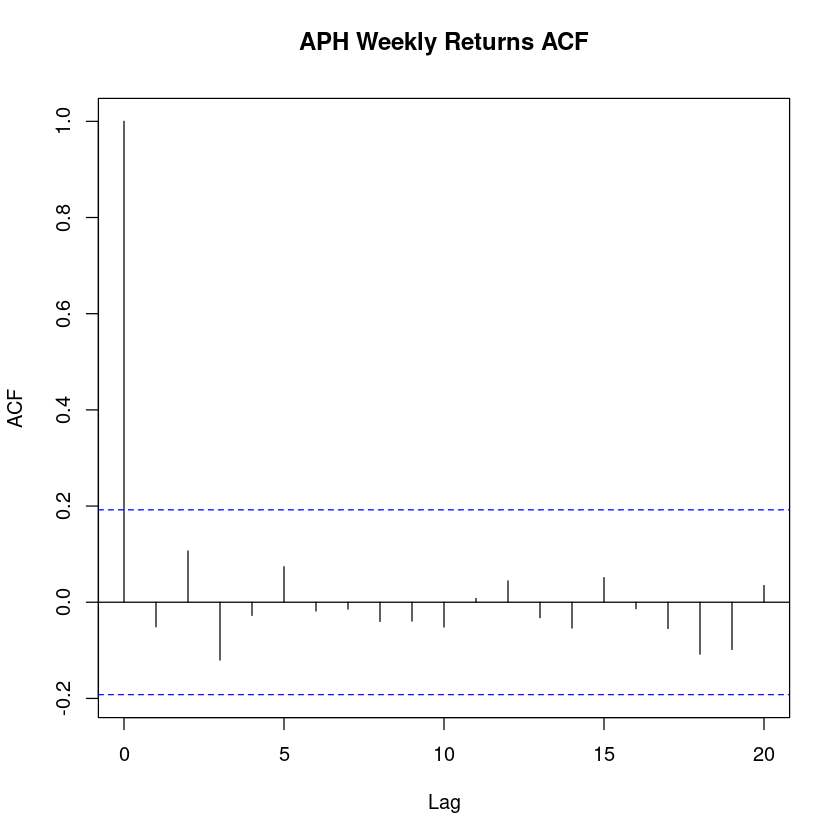

In [ ]:
#| fig-cap: "Atutocorrelation Amphenol Corp Weekly Returns"

# Filter for APH, remove NA values
aph_data <- weekly_data %>%
  filter(tic=="APH") %>%
  filter(!is.na(week_ret_prc))

  # Autocorrelation function
acf(aph_data$week_ret_prc, main="APH Weekly Returns ACF")

# Questions

How many unique tickers are in your data?

In [ ]:
length(unique(data$tic))
paste0("The data counts with ", length(unique(data$tic)), " unique tickers.")

[1] 502

[1] "The data counts with 502 unique tickers."

How many unique companies are in your data?

In [ ]:
length(unique(data$conm))
paste0("The data counts with ", length(unique(data$conm)), " unique companies.")

[1] 499

[1] "The data counts with 499 unique tickers."

Display the top 5 companies by largest mean trading volume, in a table.

In [ ]:
data %>% # We use the data
    group_by(conm) %>% # We group by company, not by ticker because we saw that some companies have more than one ticker.
    summarise(mean_trading_volume=mean(cshtrd)) %>% # Calculating the mean trading volume
    arrange(desc(mean_trading_volume)) %>% # Ordering the data in descending order
    slice(1:5) %>% # Select the top 5
    ungroup() # Ungroup the data

conm,mean_trading_volume
<chr>,<dbl>
TESLA INC,115314383
NVIDIA CORP,113131835
PALANTIR TECHNOLOG INC,60056251
APPLE INC,57736403
ADVANCED MICRO DEVICES,57143415


# Regression